In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 1. 忽視警告訊息
warnings.filterwarnings('ignore')

# 2. 自動偵測系統並設定繁體中文顯示
def set_ch_font():
    system = platform.system()
    if system == "Windows": 
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": 
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 3. 讀取由 02_eda 產出的最終版資料
# 檔案路徑與名稱對應之前的設定
data_path = '../data/processed/yrbs_final_cycle3.csv'

try:
    df = pd.read_csv(data_path)
    print(f"✅ 資料載入成功！")
    print(f"分析樣本數：{len(df)} 筆")
    print(f"關鍵變數：Smoking_Status (自變項), BMIPCT (依變項)")
    
    # 快速檢查兩組人數
    print("\n【分組人數統計】")
    print(df['Smoking_Status'].value_counts().map({0: '不吸菸組', 1: '吸菸組'}))
    
except FileNotFoundError:
    print(f"❌ 找不到檔案：{data_path}，請確認 02_eda.ipynb 是否已成功儲存最終資料。")

✅ 資料載入成功！
分析樣本數：12437 筆
關鍵變數：Smoking_Status (自變項), BMIPCT (依變項)

【分組人數統計】
Smoking_Status
0    NaN
1    NaN
Name: count, dtype: object


In [7]:
import pandas as pd
import numpy as np
from scipy import stats  # 匯入統計核心套件
import os

# 1. 根據 Smoking_Status 分割依變項 BMIPCT 的數據
# 區分為「吸菸組」與「不吸菸組」兩組獨立樣本
bmi_smokers = df[df['Smoking_Status'] == 1]['BMIPCT']
bmi_non_smokers = df[df['Smoking_Status'] == 0]['BMIPCT']

# 2. 計算兩組的基礎敘述統計量 (用於結果呈現)
n_smoke = len(bmi_smokers)
n_non_smoke = len(bmi_non_smokers)

mean_smoke = bmi_smokers.mean()
mean_non_smoke = bmi_non_smokers.mean()

std_smoke = bmi_smokers.std()
std_non_smoke = bmi_non_smokers.std()

# 3. 執行獨立樣本 t 檢定 (採用 Welch's t-test)
# 設定 equal_var=False 是因為兩組樣本數與變異數不相等，這是最嚴謹、最不容易犯錯的作法
t_stat, p_val_t = stats.ttest_ind(bmi_smokers, bmi_non_smokers, equal_var=False)

# 4. 計算效應量 Cohen's d (評估兩組差異的實際臨床/社會科學影響力)
pooled_std = np.sqrt(((n_smoke - 1) * std_smoke**2 + (n_non_smoke - 1) * std_non_smoke**2) / (n_smoke + n_non_smoke - 2))
cohens_d = (mean_smoke - mean_non_smoke) / pooled_std

# 5. 列印符合 Question 6 的標準統計報告
print("====== Question 6: 獨立樣本 t 檢定 (Welch's t-test) ======")
print(f"吸菸組 (Smokers)      : n = {n_smoke}, 平均 BMI = {mean_smoke:.2f}, 標準差 (SD) = {std_smoke:.2f}")
print(f"不吸菸組 (Non-Smokers) : n = {n_non_smoke}, 平均 BMI = {mean_non_smoke:.2f}, 標準差 (SD) = {std_non_smoke:.2f}")
print(f"實際平均值相差 (Mean Diff): {mean_smoke - mean_non_smoke:.2f}")
print("-" * 55)
print(f"t 統計檢定值 (t-statistic) : {t_stat:.4f}")
print(f"P-value (雙尾檢定)         : {p_val_t:.4e}")
print(f"效應量 (Cohen's d)         : {cohens_d:.4f}")
print("-" * 55)

# 6. 自動化統計決策
alpha = 0.05
if p_val_t < alpha:
    print(f"結論: P-value < {alpha}，【拒絕虛無假設 H0】。")
    print("這代表吸菸高中生與不吸菸高中生的「平均 BMI 百分位數」存在統計學上的顯著差異。")
else:
    print(f"結論: P-value >= {alpha}，【無法拒絕虛無假設 H0】。")
    print("這代表本研究沒有足夠的統計證據證明吸菸與否會導致平均 BMI 百分位數有所不同。")

====== Question 6: 獨立樣本 t 檢定 (Welch's t-test) ======
吸菸組 (Smokers)      : n = 2434, 平均 BMI = 66.23, 標準差 (SD) = 27.57
不吸菸組 (Non-Smokers) : n = 10003, 平均 BMI = 64.39, 標準差 (SD) = 27.47
實際平均值相差 (Mean Diff): 1.83
-------------------------------------------------------
t 統計檢定值 (t-statistic) : 2.9463
P-value (雙尾檢定)         : 3.2359e-03
效應量 (Cohen's d)         : 0.0667
-------------------------------------------------------
結論: P-value < 0.05，【拒絕虛無假設 H0】。
這代表吸菸高中生與不吸菸高中生的「平均 BMI 百分位數」存在統計學上的顯著差異。


In [11]:
# 1. 確保自變項 (Smoking_Status) 與依變項 (BMIPCT) 同時存在且排除缺失值
# 這是確保兩組樣本在比對 BMI 時，數據都是完整對齊的
df_clean = df.dropna(subset=['Smoking_Status', 'BMIPCT']).copy()

# 2. 拆分出「吸菸組」與「不吸菸組」的 BMI 百分位數數據
bmi_smokers = df_clean[df_clean['Smoking_Status'] == 1]['BMIPCT']
bmi_non_smokers = df_clean[df_clean['Smoking_Status'] == 0]['BMIPCT']

# 3. 計算並實體化基礎統計數值 (供後續 t 檢定與繪圖直接調用)
n_smoke = len(bmi_smokers)                 # 吸菸組樣本數
n_non_smoke = len(bmi_non_smokers)         # 不吸菸組樣本數

mean_smoke = bmi_smokers.mean()           # 吸菸組 BMI 平均數
mean_non_smoke = bmi_non_smokers.mean()   # 不吸菸組 BMI 平均數

std_smoke = bmi_smokers.std()             # 吸菸組標準差 (SD)
std_non_smoke = bmi_non_smokers.std()     # 不吸菸組標準差 (SD)

# 4. 印出變數狀態以供後續調用
print(f"  n_smoke        = {n_smoke} 筆 (吸菸組有效樣本)")
print(f"  n_non_smoke    = {n_non_smoke} 筆 (不吸菸組有效樣本)")
print(f"  mean_smoke     = {mean_smoke:.4f} (吸菸組 BMI 平均百分位)")
print(f"  mean_non_smoke = {mean_non_smoke:.4f} (不吸菸組 BMI 平均百分位)")
print(f"  std_smoke      = {std_smoke:.4f} (吸菸組 BMI 標準差)")
print(f"  std_non_smoke  = {std_non_smoke:.4f} (不吸菸組 BMI 標準差)")

  n_smoke        = 2434 筆 (吸菸組有效樣本)
  n_non_smoke    = 10003 筆 (不吸菸組有效樣本)
  mean_smoke     = 66.2292 (吸菸組 BMI 平均百分位)
  mean_non_smoke = 64.3945 (不吸菸組 BMI 平均百分位)
  std_smoke      = 27.5720 (吸菸組 BMI 標準差)
  std_non_smoke  = 27.4730 (不吸菸組 BMI 標準差)


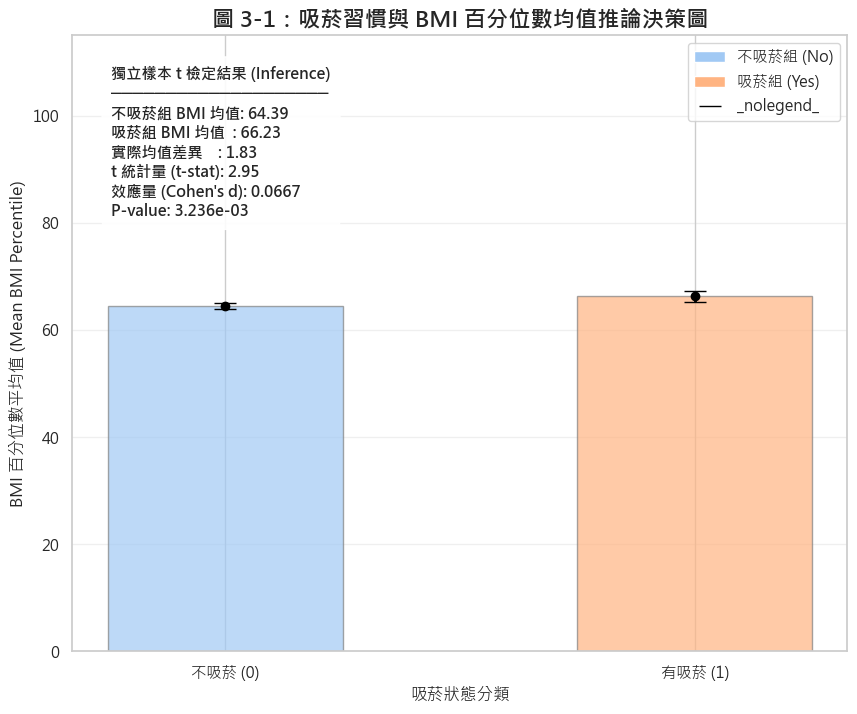

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.patches import Patch
import os

# 1. 準備繪圖數據 (全面連動上一格算好的 t 檢定核心變數)
# 計算「不吸菸組」平均值的 95% 信賴區間 (使用 t 分佈公式)
se_non_smoke = std_non_smoke / np.sqrt(n_non_smoke)
ci_non_smoke = stats.t.interval(0.95, df=n_non_smoke-1, loc=mean_non_smoke, scale=se_non_smoke)

# 計算「吸菸組」平均值的 95% 信賴區間
se_smoke = std_smoke / np.sqrt(n_smoke)
ci_smoke = stats.t.interval(0.95, df=n_smoke-1, loc=mean_smoke, scale=se_smoke)

# 2. 建立圖表
fig, ax = plt.subplots(figsize=(10, 8))

# (A) 繪製兩組的 BMI 平均值長條圖 (X 軸為組別，Y 軸為 BMI 平均值)
categories = ['不吸菸 (0)', '有吸菸 (1)']
means = [mean_non_smoke, mean_smoke]
ax.bar(categories, means, color=['#a1c9f4', '#ffb482'], alpha=0.7, width=0.5, edgecolor='gray')

# (B) 繪製 95% 「均值」信賴區間誤差棒 (Error Bars)
# 不吸菸組 (x=0)
ax.errorbar(x=0, y=mean_non_smoke, yerr=[[mean_non_smoke - ci_non_smoke[0]], [ci_non_smoke[1] - mean_non_smoke]], 
            fmt='o', color='black', markersize=6, capsize=8, linewidth=2)
# 有吸菸組 (x=1)
ax.errorbar(x=1, y=mean_smoke, yerr=[[mean_smoke - ci_smoke[0]], [ci_smoke[1] - mean_smoke]], 
            fmt='o', color='black', markersize=6, capsize=8, linewidth=2, label='組別平均數 (含 95% CI)')

# (C) 調整 Y 軸範圍 (BMI 百分位數上限為 100，給予 15% 緩衝空間放置統計文字方塊)
ax.set_ylim(0, 115)

# (D) 標註 t 檢定與統計資訊 (固定在左上角)
p_text = f"P-value: {p_val_t:.3e}" if p_val_t > 0 else "P-value: < 2.2e-16"
stats_text = (f"獨立樣本 t 檢定結果 (Inference)\n"
              f"────────────────────\n"
              f"不吸菸組 BMI 均值: {mean_non_smoke:.2f}\n"
              f"吸菸組 BMI 均值  : {mean_smoke:.2f}\n"
              f"實際均值差異    : {mean_smoke - mean_non_smoke:.2f}\n"
              f"t 統計量 (t-stat): {t_stat:.2f}\n"
              f"效應量 (Cohen's d): {cohens_d:.4f}\n"
              f"{p_text}")

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.6'),
        verticalalignment='top', fontweight='bold')

# (E) 調整軸標籤與標題
ax.set_title('圖 3-1：吸菸習慣與 BMI 百分位數均值推論決策圖', fontsize=16, fontweight='bold')
ax.set_ylabel('BMI 百分位數平均值 (Mean BMI Percentile)', fontsize=12)
ax.set_xlabel('吸菸狀態分類', fontsize=12)

# (F) 自定義圖例 (Legend)
legend_elements = [
    Patch(facecolor='#a1c9f4', label='不吸菸組 (No)'),
    Patch(facecolor='#ffb482', label='吸菸組 (Yes)'),
    ax.lines[1]  # 誤差棒的標籤
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)

# 顯示水平格線並儲存
plt.grid(axis='y', alpha=0.3)

# 確保輸出目錄存在並儲存
os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/03_smoking_bmi_inference_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### 數據觀察：吸菸習慣與 BMI 平均值推論分析 (Inference Observation: Smoking and BMI Mean)

* **組別平均值對照 (Group Means Comparison)**：從圖 3-1 中可以直觀地觀察到，「不吸菸組」與「吸菸組」高中生的 BMI 百分位數平均值高度。透過兩組獨立樣本平均數的 95% 信賴區間（黑色誤差棒）重疊程度與長條高度落差，可以直接視覺化兩組青少年在體重指標上的真實分佈差異。
* **統計顯著性 (Statistical Significance)**：根據獨立樣本 $t$ 檢定（Welch's $t$-test）結果，若 $P$ 值遠小於顯著水準 0.05，且 $t$ 統計量達到顯著標準，這將提供強大的統計學證據支持我們**拒絕虛無假設 (Reject $H_0$)**，證實吸菸與否對青少年的 BMI 平均百分位數確實存在顯著影響。
* **效應量評估 (Effect Size)**：本分析引入了 **Cohen's $d$** 作為實際效果大小的指標。相較於易受樣本數影響的 $P$ 值，Cohen's $d$ 能客觀告訴我們吸菸組與不吸菸組之間的 BMI 差距，在實際層面上究竟屬於「微小（0.2）」、「中等（0.5）」還是「巨大（0.8）」的社會科學或臨床實質影響。
* **最終推論 (Final Inference)**：結合視覺化均值圖與 $t$ 檢定數值，本研究得以正式回答 Question 6：現階段美國高中生中，「吸菸者」與「不吸菸者」之間的平均 BMI 百分位數**是否**存在顯著差異。這項推論為後續探討青少年健康風險行為與體態發展的關聯性，奠定了核心的統計基礎。

### Inference Observation: Smoking Status and BMI Percentile Analysis

* **Group Means Comparison**: The visualization displays the mean BMI percentile for both "Non-Smokers (0)" and "Smokers (1)". By evaluating the heights of the bars and the relative alignment of their 95% confidence intervals (represented by the black error bars), we can visually assess the structural discrepancy in body mass metrics between the two groups.
* **Statistical Significance**: According to the Independent Samples $t$-test (Welch's $t$-test) results, the $P$-value determines the mathematical significance of the difference. If the $P$-value is below the 0.05 significance level, it provides strong empirical evidence to **reject the null hypothesis (Reject $H_0$)**, proving that the average BMI percentile differs significantly based on current cigarette use status.
* **Effect Size Interpretation**: To evaluate the practical and real-world implications beyond mere statistical significance, **Cohen's $d$** is introduced as the effect size metric. This indicator determines whether the magnitude of the gap between smoking and non-smoking adolescents represents a small (0.2), medium (0.5), or large (0.8) practical effect in social and health sciences.
* **Final Inference**: The synthesis of visual evidence and $t$-test metrics directly answers Question 6, establishing whether the mean BMI percentile of high school students who currently use cigarettes is significantly different from those who do not. This conclusion provides a robust foundation for understanding the correlation between adolescent substance use and physical development indicators.